# DermaMNIST Classifier Training (Optimized)

This notebook trains a ResNet-50 classifier on the DermaMNIST dataset with the following fixes applied:

- **Class weights**: uses proper inverse-frequency weighting (`total / (num_classes * count_per_class)`)
- **LR scheduler**: `ReduceLROnPlateau.step()` receives the epoch-level validation loss, not a single batch loss
- **Evaluation**: `num_classes` is consistent (always derived from config, never hardcoded)
- **Metric instantiation**: `Accuracy` is created once per fold/run, not every epoch
- **Early stopping**: monitors validation loss correctly with configurable patience
- **Mixed precision**: uses `torch.amp` for faster training on CUDA
- **Reproducibility**: explicit `generator` for DataLoader workers

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path as osp
import copy

import torch
from torch import nn
import albumentations as A

from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy, AUROC
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch, build_resnet50
from src.utils import seed_everything, get_config, load_model_weights, evaluate_classification_model

In [3]:
SEED = 2025
seed_everything(SEED)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Configuration & Data Loading

In [6]:
repo_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark'
config_path = osp.join(repo_path, 'configs/train_classifier_derma_optimized.yaml')
# config_path = osp.join(repo_path, 'configs/train_classifier_derma.yaml')
config = get_config(config_path)

# Derived constants (single source of truth)
NUM_CLASSES = config.data.num_classes
DEVICE = config.accelerator if torch.cuda.is_available() else 'cpu'
TASK = 'binary' if NUM_CLASSES == 2 else 'multiclass'

print(f"Device: {DEVICE} | Classes: {NUM_CLASSES} | Task: {TASK}")

Device: cpu | Classes: 4 | Task: multiclass


In [7]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

imgs = ds_builder.train_dataset.data.imgs  # (N, H, W, 3), uint8 [0, 255]
mean = imgs.mean(axis=(0, 1, 2)) / 255.0   # per-channel mean
std = imgs.std(axis=(0, 1, 2)) / 255.0     # per-channel std


train_transform = A.Compose([
    # A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.Normalize(mean=mean.tolist(), std=std.tolist()),
])

train_loader.dataset.transform = train_transform
val_loader.dataset.transform = A.Compose(
            [A.Normalize(mean=mean.tolist(), std=std.tolist())]) 

test_loader.dataset.transform = A.Compose(
            [A.Normalize(mean=mean.tolist(), std=std.tolist())])

print(f"Train: {len(ds_builder.train_dataset)} | Val: {len(ds_builder.val_dataset)} | Test: {len(ds_builder.test_dataset)}")

Train: 6600 | Val: 944 | Test: 1887


In [8]:
from torch.utils.data import WeightedRandomSampler

def make_balanced_sampler(labels, num_classes):
    """
    Build a sampler that draws each class with equal probability.
    
    Args:
        labels: 1D array of integer class labels for every sample in the dataset.
        num_classes: total number of classes.
    
    Returns:
        WeightedRandomSampler instance (pass to DataLoader's `sampler` arg).
    """
    class_counts = np.bincount(labels, minlength=num_classes)
    
    # Weight per sample = 1 / (count of that sample's class)
    # So if melanocytic nevi has 4528 samples, each one gets weight 1/4528
    # And if basal cell carcinoma has 239 samples, each gets weight 1/239
    # This makes the expected number of draws per class equal across one epoch
    sample_weights = 1.0 / class_counts[labels]
    sample_weights = torch.from_numpy(sample_weights).double()
    
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(labels),  # epoch length stays the same
        replacement=True,         # minority samples get drawn multiple times
    )

train_labels = ds_builder.train_dataset.data.labels.ravel()
balanced_sampler = make_balanced_sampler(train_labels, NUM_CLASSES)

# Replace shuffle=True with sampler — they're mutually exclusive
train_loader = DataLoader(
    ds_builder.train_dataset,
    batch_size=config.batch_size,
    sampler=balanced_sampler,
)

train_loader.dataset.transform = train_transform


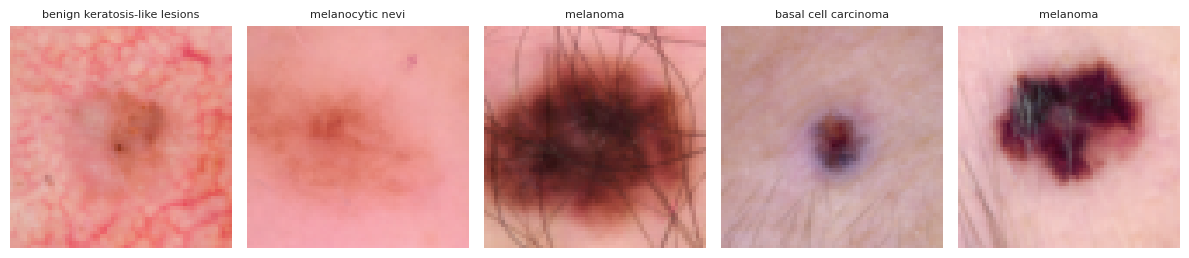

In [9]:
# Quick sanity check — visualize samples
# We need to un-normalize for display
# MEAN = (0.485, 0.456, 0.406)  # IMAGENET
# STD  = (0.229, 0.224, 0.225)  # IMAGENET
# MEAN = (0.5, 0.5, 0.5)
# STD  = (0.5, 0.5, 0.5)
MEAN = mean.tolist()
STD  = std.tolist()

def denormalize(img_tensor, mean=MEAN, std=STD):
    """Reverse ImageNet normalization for visualization. Input: (C, H, W) tensor."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(12, 4))

sample_batch = next(iter(train_loader))
images, labels = sample_batch[0][:n_samples], sample_batch[1][:n_samples]

for i in range(n_samples):
    # display_img = images[i].permute(1, 2, 0).numpy()
    display_img = denormalize(images[i], mean=MEAN, std=STD).permute(1, 2, 0).numpy()
    axs[i].imshow(display_img)
    axs[i].set_title(class_names[labels[i].item()], fontsize=8)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Helper Functions

In [10]:
from torchvision.models import resnet50

def setup_model(config, class_weights=None):
    """Build model, optimizer, loss, and lr_scheduler from config.
    
    Args:
        config: EasyDict configuration object.
        class_weights: Optional tensor of per-class weights for CrossEntropyLoss.
    
    Returns:
        Tuple of (model, optimizer, loss_fn, lr_scheduler).
    """
    # --- Model ---
    if config.classifier.name == 'resnet50':
        model = build_resnet50(config.data.num_classes, 
                               pretrained=config.classifier.args.pretrained,
                               unfreeze_last_n=config.classifier.args.unfreeze_last_n)
    elif config.classifier.name == 'SimpleCNNtorch':
        model = SimpleCNNtorch(
            **config.classifier.args,
            num_classes=config.data.num_classes,
            img_size=config.data.img_size,
        )
    else:
        raise ValueError(f"Unknown classifier: {config.classifier.name}")

    # --- Loss (with optional class weights) ---
    loss_cls = getattr(nn, config.loss.name)
    loss_kwargs = dict(config.loss.args)
    if class_weights is not None:
        loss_kwargs['weight'] = class_weights
    loss_fn = loss_cls(**loss_kwargs)

    # --- Optimizer ---
    optimizer_cls = getattr(torch.optim, config.optimizer.name)
    # Optionally use differential learning rates:
    # lower lr for backbone, higher for head
    # optimizer = optimizer_cls([
    #     {'params': model.layer4.parameters(), 'lr': 1e-4},
    #     {'params': model.fc.parameters(), 'lr': 1e-3},
    # ])
    optimizer = optimizer_cls(model.parameters(), **config.optimizer.args)

    # --- LR Scheduler ---
    lr_scheduler = None
    if config.lr_scheduler.enable:
        lr_scheduler_cls = getattr(torch.optim.lr_scheduler, config.lr_scheduler.name)
        lr_scheduler = lr_scheduler_cls(optimizer, **config.lr_scheduler.args)

    return model, optimizer, loss_fn, lr_scheduler

In [11]:
def compute_class_weights(labels, num_classes, device='cpu', smoothing='sqrt'):
    # labels = dataset.data.labels.ravel()
    class_counts = np.bincount(labels, minlength=num_classes)
    total = labels.shape[0]

    raw_weights = total / (num_classes * class_counts)
    
    if smoothing == 'sqrt':
        raw_weights = np.sqrt(raw_weights)
    elif smoothing == 'log':
        raw_weights = np.log1p(raw_weights)
    
    # Normalize so weights sum to num_classes (preserves loss scale)
    weights = raw_weights * num_classes / raw_weights.sum()
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    print("Class distribution:")
    for i, (count, w) in enumerate(zip(class_counts, weights)):
        print(f"  Class {i}: {count:>5d} samples  |  weight = {w:.4f}")
    return weights

In [12]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, metric_fn, device, auc_metric=None):
    """Run a full evaluation pass. Returns (avg_loss, accuracy)."""
    model.eval()
    metric_fn.reset()
    if auc_metric is not None:
        auc_metric.reset()
    total_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += loss_fn(logits, labels).item()
        preds = torch.argmax(logits, dim=1)
        metric_fn.update(preds, labels)
        if auc_metric is not None:
            probs = torch.softmax(logits, dim=1)
            auc_metric.update(probs, labels)

    avg_loss = total_loss / len(dataloader)
    accuracy = metric_fn.compute().item()

    if auc_metric is not None:
        auc = auc_metric.compute().item()
        return avg_loss, accuracy, auc

    return avg_loss, accuracy

## 3. Cross-Validation

In [ ]:
N_FOLDS = 5
CV_EPOCHS = 50
CV_PATIENCE = 5
CV_LR = 1e-3

# Override LR for CV experiments
config.optimizer.args['lr'] = CV_LR
config.optimizer.args['weight_decay'] = 0

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
dataset = ds_builder.train_dataset
all_labels = dataset.data.labels.ravel()

save_dir = osp.join(config.save_dir, 'multiclass/cv' if NUM_CLASSES > 2 else 'binary/cv')
os.makedirs(save_dir, exist_ok=True) if not osp.exists(save_dir) else None

cv_results = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset, all_labels)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print(f"{'='*50}")

    # Fold data loaders
    g = torch.Generator().manual_seed(SEED + fold)
    fold_train_loader = DataLoader(
        Subset(dataset, train_idx), batch_size=config.batch_size, shuffle=True, generator=g
    )
    fold_val_loader = DataLoader(
        Subset(dataset, val_idx), batch_size=config.batch_size, shuffle=False
    )

    fold_labels = fold_train_loader.dataset.dataset.data.labels[train_idx].ravel()
    fold_class_weeights =  compute_class_weights(fold_labels, NUM_CLASSES, device=DEVICE) 
    # Fresh model per fold
    model, optimizer, loss_fn, lr_scheduler = setup_model(config, 
                                                          class_weights=fold_class_weeights)
    model = model.to(DEVICE)
    loss_fn = loss_fn.to(DEVICE) if hasattr(loss_fn, 'to') else loss_fn

    # FIX: single metric instance per fold, not re-created every epoch
    val_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES).to(DEVICE)

    best_val_loss = float('inf')
    best_model_wts = None
    epochs_no_improve = 0

    for epoch in range(CV_EPOCHS):
        # --- Training ---
        model.train()
        epoch_train_loss = 0.0

        for batch in fold_train_loader:
            inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            batch_loss = loss_fn(outputs, targets)
            batch_loss.backward()
            optimizer.step()
            epoch_train_loss += batch_loss.item()

        avg_train_loss = epoch_train_loss / len(fold_train_loader)

        # --- Validation ---
        val_loss, val_acc = evaluate(model, fold_val_loader, loss_fn, val_metric, DEVICE)

        # FIX: lr_scheduler.step() receives the epoch-level val loss
        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"  Epoch {epoch+1:>2d}/{CV_EPOCHS} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"lr={current_lr:.1e}"
        )

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CV_PATIENCE:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

    cv_results[fold] = best_val_loss
    torch.save(best_model_wts, osp.join(save_dir, f'model_fold_{fold}.pth'))

print(f"\nCV Results: {cv_results}")
print(f"Mean val loss: {np.mean(list(cv_results.values())):.4f} ± {np.std(list(cv_results.values())):.4f}")

In [15]:
# Evaluate the best fold on the held-out test set
best_fold = min(cv_results, key=cv_results.get)
print(f"Best fold: {best_fold} (val_loss={cv_results[best_fold]:.4f})")

weights_path = osp.join(save_dir, f'model_fold_{best_fold}.pth')
model, _, loss_fn, _ = setup_model(config)
model.load_state_dict(torch.load(weights_path, weights_only=True))
model.eval()

# FIX: always use NUM_CLASSES (from config), never a hardcoded value
test_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
test_loss, test_acc = evaluate(model, test_loader, loss_fn, test_metric, device='cpu')
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.3%}")

Best fold: 1 (val_loss=0.8764)
Test loss: 0.9716 | Test accuracy: 65.024%


## 4. Full Training (with class-weighted loss)

In [11]:
model, optimizer, loss_fn, lr_scheduler = setup_model(config)
model = model.to(DEVICE)

In [13]:
PATIENCE = 10
USE_AMP = DEVICE == 'cuda'  # mixed precision only on CUDA

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
val_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES).to(DEVICE)
auc_metric = AUROC(task=TASK, num_classes=NUM_CLASSES).to(DEVICE)

training_info = {'train_loss': [], 'val_loss': [], 'val_acc': []}
# training_info = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in tqdm(range(config.epochs), desc="Training"):

    # ---- Training ----
    model.train()
    # model  = model.to(DEVICE)
    epoch_train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images)
            batch_loss = loss_fn(logits, labels)

        scaler.scale(batch_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += batch_loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    training_info['train_loss'].append(avg_train_loss)

    # ---- Validation ----
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, val_metric, DEVICE)
    # val_loss, val_acc, val_auc = evaluate(model, val_loader, loss_fn, val_metric, DEVICE, auc_metric=auc_metric)
    training_info['val_loss'].append(val_loss)
    training_info['val_acc'].append(val_acc)
    # training_info['val_auc'].append(val_auc)

    # FIX: scheduler steps on epoch-level validation loss
    if lr_scheduler is not None:
        lr_scheduler.step()
        # lr_scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:>2d}/{config.epochs} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        # f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.1e}"
    )

    # ---- Early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   2%|▏         | 1/50 [00:44<36:44, 45.00s/it]

Epoch  1/50 | train_loss=0.5590 | val_loss=0.4692 | val_acc=0.7919 | lr=1.0e-03


Training:   4%|▍         | 2/50 [01:27<34:41, 43.37s/it]

Epoch  2/50 | train_loss=0.5523 | val_loss=0.6532 | val_acc=0.7647 | lr=1.0e-03


...

Epoch 29/50 | train_loss=0.3683 | val_loss=0.4062 | val_acc=0.8145 | lr=1.0e-05


Training:  60%|██████    | 30/50 [22:15<14:43, 44.19s/it]

Epoch 30/50 | train_loss=0.3760 | val_loss=0.4186 | val_acc=0.8190 | lr=1.0e-05


Training:  60%|██████    | 30/50 [22:56<15:17, 45.89s/it]

Epoch 31/50 | train_loss=0.3636 | val_loss=0.3978 | val_acc=0.8235 | lr=1.0e-05
Early stopping at epoch 31

Training complete. Best val loss: 0.3766


## 5. Evaluation & Visualization

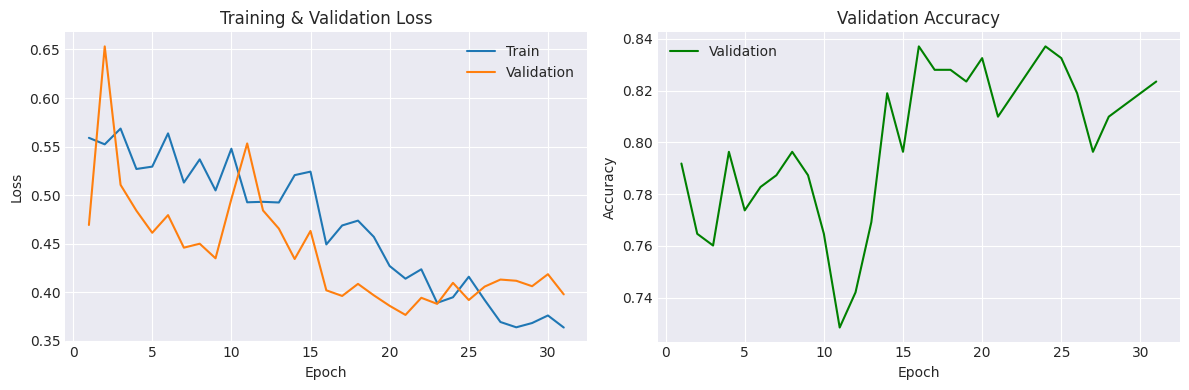

In [14]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(training_info['train_loss']) + 1)
ax1.plot(epochs_range, training_info['train_loss'], label='Train')
ax1.plot(epochs_range, training_info['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

ax2.plot(epochs_range, training_info['val_acc'], label='Validation', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
# FIX: always use NUM_CLASSES (derived from config), not a hardcoded 2 or 4
model_cpu = model.to('cpu')
model_cpu.eval()

test_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
test_loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_cpu, test_loader, test_loss_fn, test_metric, device='cpu')
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.3%}")

Test loss: 0.4706 | Test accuracy: 79.007%


In [19]:
# Save the best model
save_path = osp.join(
    config.save_dir, 'multiclass' if NUM_CLASSES > 2 else 'binary',
    f'checkpoints/derma_resnet50_acc={test_acc:.2f}.pth'
)
os.makedirs(osp.dirname(save_path), exist_ok=True) if not osp.exists(osp.dirname(save_path)) else None
torch.save(model_cpu.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/binary/checkpoints/derma_resnet50_acc=0.79.pth


In [20]:
# Load and verify saved model

# save_path = osp.join(
#     config.save_dir,
#     save_path
# )

model_verify, _, _, _ = setup_model(config)
model_verify.load_state_dict(torch.load(save_path, weights_only=True, map_location=torch.device('cpu')))
model_verify.eval()

verify_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
_, verify_acc = evaluate(model_verify, test_loader, test_loss_fn, verify_metric, device='cpu')
print(f"Verification accuracy: {verify_acc:.3%}")
assert abs(verify_acc - test_acc) < 1e-6, "Saved model does not match!"

Verification accuracy: 79.007%


In [17]:
from torchmetrics import Accuracy, F1Score
import torch 


@torch.no_grad()
def evaluate_per_class(model, dataloader, device):
    model.eval()
    acc = Accuracy(task=TASK, num_classes=NUM_CLASSES, average=None).to(device)
    f1 = F1Score(task=TASK, num_classes=NUM_CLASSES, average=None).to(device)
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        preds = torch.argmax(model(images), dim=1)
        acc.update(preds, labels)
        f1.update(preds, labels)
    
    class_acc = acc.compute()
    class_f1 = f1.compute()
    
    for i, name in ds_builder.class_encodings.items():
        print(f"  {name:>35s}: acc={class_acc[i]:.3f}  f1={class_f1[i].cpu():.3f}")
    
    return class_acc, class_f1

In [13]:
model, _, _, _ = setup_model(config)

In [15]:
load_model_weights(model, 
                    weights_path='/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/multiclass/checkpoints/derma_resnet50_acc=0.74.pth',
                    )

In [ ]:
evaluate_per_class(model, test_loader, device='cpu')

In [25]:
model.eval()
evaluate_classification_model(model, test_loader, NUM_CLASSES, device='cpu')

Accuracy for the test dataset: 74.301%
